In [1]:
import json
import pandas as pd

# Load the JSON file
with open("preprocessed_metrics.json", "r") as f:
    data = json.load(f)

# Create a list to collect results
results = []

# Loop through each entry in the JSON
for entry in data:
    simulation_index = entry["simulation_index"]
    search_method = entry["search_method"]
    success_vector = entry["success_epochs"]

    # Compute success rate = number of True / total
    success_rate = sum(success_vector) / len(success_vector)

    results.append({
        "simulation_index": simulation_index,
        "search_method": search_method,
        "success_rate": success_rate
    })

# Convert to DataFrame for easy viewing / analysis
df_results = pd.DataFrame(results)

# Aggregate in case there are duplicates (averaging over same index & method)
df_summary = df_results.groupby(["simulation_index", "search_method"], as_index=False)["success_rate"].mean()

# Display the final summarized table
display(df_summary)


,simulation_index,search_method,success_rate
0,55,BASELINE,0.85
1,55,DIRICHLET,0.87
2,55,HYBRID,1.00
3,55,RANDOM,0.52
4,56,BASELINE,1.00
5,56,DIRICHLET,0.94
6,56,HYBRID,1.00
7,56,RANDOM,0.43


In [2]:

import numpy as np
from collections import defaultdict

# Organize entries by simulation index
sim_groups = defaultdict(list)
for entry in data:
    sim_groups[entry["simulation_index"]].append(entry)

# Prepare results
joint_success_results = []

for sim_idx, entries in sim_groups.items():
    # Ensure we have all four search methods for this simulation
    methods = [e["search_method"] for e in entries]
    if len(entries) < 4:
        print(f"Warning: simulation {sim_idx} has fewer than 4 methods.")
        continue

    # Step 1: Determine indexes (epochs) where all methods succeeded
    # Create an array of boolean success masks per method
    success_masks = [np.array(e["success_epochs"], dtype=bool) for e in entries]
    min_len = min(len(mask) for mask in success_masks)  # handle possible unequal lengths
    joint_success_mask = np.all([mask[:min_len] for mask in success_masks], axis=0)

    # Step 2: Compute stats for each method only on those epochs
    for entry in entries:
        method = entry["search_method"]

        num_actions = np.array(entry["num_actions_epochs"][:min_len])[joint_success_mask]
        distances = np.array(entry["travelled_distance_epochs"][:min_len])[joint_success_mask]
        loc_errors = np.array(entry["location_error_epochs"][:min_len])[joint_success_mask]

        if len(num_actions) == 0:
            # No jointly successful epochs → skip
            continue

        result = {
            "simulation_index": sim_idx,
            "search_method": method,
            "n_joint_success": len(num_actions),
            "mean_num_actions": np.mean(num_actions),
            "std_num_actions": np.std(num_actions),
            "mean_distance": np.mean(distances),
            "std_distance": np.std(distances),
            "mean_loc_error": np.mean(loc_errors),
            "std_loc_error": np.std(loc_errors)
        }
        joint_success_results.append(result)

# Create DataFrame
df_joint = pd.DataFrame(joint_success_results)

# Sort nicely by simulation index and method
df_joint = df_joint.sort_values(by=["simulation_index", "search_method"]).reset_index(drop=True)

# Display the joint-success summary
display(df_joint)


,simulation_index,search_method,n_joint_success,mean_num_actions,std_num_actions,mean_distance,std_distance,mean_loc_error,std_loc_error
0,55,BASELINE,41,12.170732,7.534967,1.908062,1.418002,0.121300,0.000390
1,55,DIRICHLET,41,13.000000,9.255190,2.072118,1.782647,0.121300,0.000390
2,55,HYBRID,41,20.658537,27.058752,4.050347,5.682278,0.122225,0.008043
3,55,RANDOM,41,37.560976,35.531538,3.046354,2.979832,0.120761,0.000728
4,56,BASELINE,40,235.100000,138.643572,49.992848,28.816787,0.206082,0.011424
5,56,DIRICHLET,40,140.850000,82.547123,31.447692,19.431293,0.220448,0.010781
6,56,HYBRID,40,109.100000,73.328985,25.668805,17.377277,0.213072,0.013458
7,56,RANDOM,40,244.325000,267.685393,21.458036,22.540757,0.224421,0.034454



--- Simulation Index 55 ---


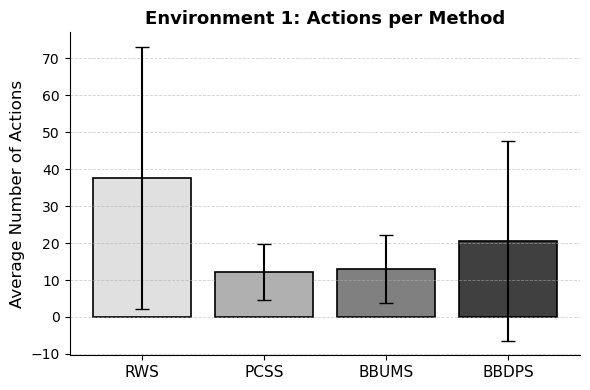

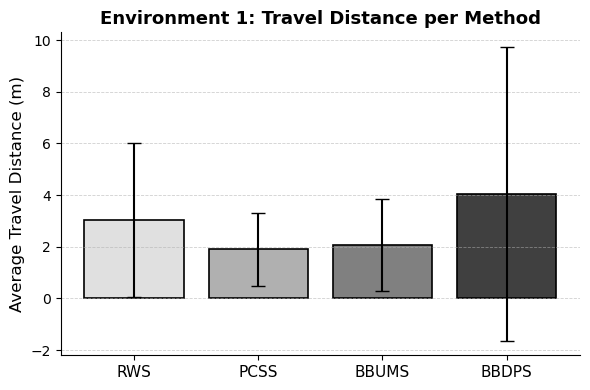

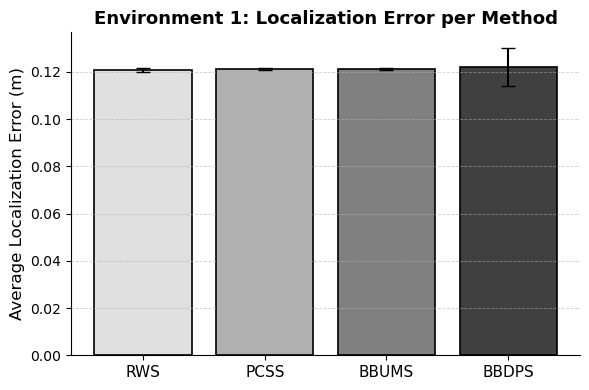


--- Simulation Index 56 ---


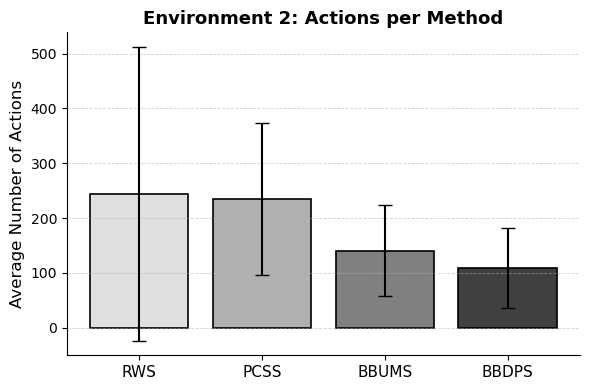

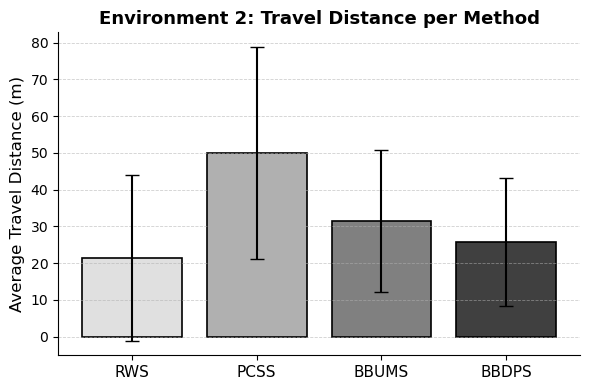

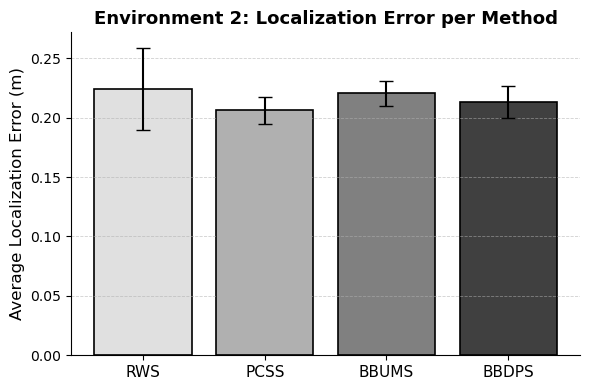

In [5]:
import matplotlib.pyplot as plt
import numpy as np

# === Configuration ===
# Replace method names and set display order
method_order = ["RANDOM", "BASELINE", "DIRICHLET", "HYBRID"]
display_names = {
    "RANDOM": "RWS",
    "BASELINE": "PCSS",
    "DIRICHLET": "BBUMS",
    "HYBRID": "BBDPS"
}

# Greyscale shades (lighter → darker)
greys = ["#e0e0e0", "#b0b0b0", "#808080", "#404040"]

# === Plotting Function ===
def plot_metric(df, metric_mean, metric_std, ylabel, title):
    fig, ax = plt.subplots(figsize=(6, 4))

    x = np.arange(len(method_order))
    means = [df.loc[df["search_method"] == m, metric_mean].values[0] for m in method_order]
    stds = [df.loc[df["search_method"] == m, metric_std].values[0] for m in method_order]

    # Draw bars in grayscale with error bars for ±1 std
    bars = ax.bar(x, means, yerr=stds, capsize=5, color=greys, edgecolor="black", linewidth=1.2)

    # Labels and style
    ax.set_xticks(x)
    ax.set_xticklabels([display_names[m] for m in method_order], fontsize=11)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.grid(True, axis='y', linestyle='--', linewidth=0.6, alpha=0.6)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    plt.tight_layout()
    plt.show()

# === Generate plots for each simulation index ===
for sim_idx in sorted(df_joint["simulation_index"].unique()):
    df_sim = df_joint[df_joint["simulation_index"] == sim_idx]

    print(f"\n--- Simulation Index {sim_idx} ---")

    if sim_idx == 55:
        title = "Environment 1"
    elif sim_idx == 56:
        title = "Environment 2"

    plot_metric(df_sim, "mean_num_actions", "std_num_actions",
                ylabel="Average Number of Actions",
                title=f"{title}: Actions per Method")

    plot_metric(df_sim, "mean_distance", "std_distance",
                ylabel="Average Travel Distance (m)",
                title=f"{title}: Travel Distance per Method")

    plot_metric(df_sim, "mean_loc_error", "std_loc_error",
                ylabel="Average Localization Error (m)",
                title=f"{title}: Localization Error per Method")
